## Phase 4 — Return Rate Scenario Insights (2022)

Using a baseline return rate of 98%, aligned with reported German deposit-return performance, scenario simulations were conducted to evaluate environmental sensitivity to compliance changes.

### Key findings:

A reduction to 95% return rate results in ~30,000 tonnes less CO₂ avoided.

A further decline to 93% increases losses to over 50,000 tonnes.

Improving the system from 98% to 100% yields only ~20,000 additional tonnes avoided.

This demonstrates:

The German Pfand system operates near saturation.

Environmental risk is asymmetric: losses from declining compliance are larger than gains from marginal improvement.

Policy enforcement stability is more critical than incremental optimization.

These findings highlight the system’s high efficiency but also its vulnerability to compliance erosion.


### Assumptions & Scope

pfand_input_kt interpreted as collected mass entering recycling system.

Total placed-on-market mass estimated using baseline 98% return rate.

Recycling efficiency held constant across scenarios.

CO₂ factors applied for Glas, Aluminium, and Kunststoff only (Eisenmetalle excluded due to missing emission factor).

Model represents static 2022 volume conditions (no demand growth included).

In [7]:
import pandas as pd
import numpy as np
# Step 4.1 — Load + Baseline Prep

# 1) Load master file
df = pd.read_csv("../data/cleaned/pfand_2022_master.csv")

# 2) Clean column names just in case
df.columns = [c.strip() for c in df.columns]

# 3) Keep only materials that have CO2 factors in your Phase 3 file
keep_materials = ["Glas", "Aluminium", "Kunststoff"]
df = df[df["material"].isin(keep_materials)].copy()

# 4) Ensure numeric types (handles if strings slipped through)
num_cols = ["pfand_input_kt", "total_recycled_kt", "recycling_rate_pct"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 5) Baseline assumption (Germany Pfand system)
BASELINE_RETURN_RATE = 0.98

# 6) Interpret pfand_input_kt as "returned/collected input mass"
#    Reverse-engineer estimated mass placed on market
df["placed_kt_est"] = df["pfand_input_kt"] / BASELINE_RETURN_RATE

# 7) Recompute recycled mass from returned input + recycling rate
df["recycled_kt_recalc"] = df["pfand_input_kt"] * (df["recycling_rate_pct"] / 100)

# 8) Compare recalculated vs your dataset's total_recycled_kt
df["recycled_diff_kt"] = df["recycled_kt_recalc"] - df["total_recycled_kt"]
df["recycled_diff_pct"] = np.where(
    df["total_recycled_kt"] > 0,
    (df["recycled_diff_kt"] / df["total_recycled_kt"]) * 100,
    np.nan
)

# 9) Show the key baseline validation table
cols_to_show = [
    "material",
    "pfand_input_kt",
    "placed_kt_est",
    "recycling_rate_pct",
    "total_recycled_kt",
    "recycled_kt_recalc",
    "recycled_diff_kt",
    "recycled_diff_pct"
]
display(df[cols_to_show].sort_values("material"))


,material,pfand_input_kt,placed_kt_est,recycling_rate_pct,total_recycled_kt,recycled_kt_recalc,recycled_diff_kt,recycled_diff_pct
1,Aluminium,50.4,51.428571,99.2,50.0,49.9968,-0.0032,-0.006400
0,Glas,35.4,36.122449,99.2,35.1,35.1168,0.0168,0.047863
2,Kunststoff,463.5,472.959184,95.3,441.7,441.7155,0.0155,0.003509


In [8]:
# ----------------------------
# Step 4.2 — Scenario Modeling
# ----------------------------

# Load CO2 factors
co2 = pd.read_csv("../data/cleaned/phase3_co2e_avoided_2022_by_material.csv")
co2 = co2[co2["material"].isin(["Glas", "Aluminium", "Kunststoff"])]

# Merge with master dataframe
df_scen = df.merge(
    co2[["material", "co2e_saved_kg_per_kg"]],
    on="material",
    how="left"
)

# Scenario return rates
scenarios = {
    "Baseline_98%": 0.98,
    "Weak_95%": 0.95,
    "Relaxed_93%": 0.93,
    "Improved_99%": 0.99,
    "Max_100%": 1.00
}

results = []

for name, rate in scenarios.items():
    
    temp = df_scen.copy()
    
    # Step 1 — Returned mass under scenario
    temp["returned_kt"] = temp["placed_kt_est"] * rate
    
    # Step 2 — Recycled mass
    temp["recycled_kt"] = temp["returned_kt"] * (temp["recycling_rate_pct"] / 100)
    
    # Step 3 — Convert kt to kg
    temp["recycled_kg"] = temp["recycled_kt"] * 1_000_000
    
    # Step 4 — CO2 avoided
    temp["co2e_avoided_kg"] = temp["recycled_kg"] * temp["co2e_saved_kg_per_kg"]
    
    total_co2_tonnes = temp["co2e_avoided_kg"].sum() / 1000
    
    results.append({
        "Scenario": name,
        "Return_Rate": rate,
        "Total_CO2_Avoided_tonnes": total_co2_tonnes
    })

scenario_df = pd.DataFrame(results)

display(scenario_df)


,Scenario,Return_Rate,Total_CO2_Avoided_tonnes
0,Baseline_98%,0.98,9.910820e+05
1,Weak_95%,0.95,9.607427e+05
2,Relaxed_93%,0.93,9.405166e+05
3,Improved_99%,0.99,1.001195e+06
4,Max_100%,1.00,1.011308e+06


In [9]:
# ----------------------------
# Compare vs Baseline
# ----------------------------

baseline_value = scenario_df.loc[
    scenario_df["Scenario"] == "Baseline_98%",
    "Total_CO2_Avoided_tonnes"
].values[0]

scenario_df["Delta_vs_Baseline_tonnes"] = (
    scenario_df["Total_CO2_Avoided_tonnes"] - baseline_value
)

display(scenario_df)


,Scenario,Return_Rate,Total_CO2_Avoided_tonnes,Delta_vs_Baseline_tonnes
0,Baseline_98%,0.98,9.910820e+05,0.000000
1,Weak_95%,0.95,9.607427e+05,-30339.244469
2,Relaxed_93%,0.93,9.405166e+05,-50565.407449
3,Improved_99%,0.99,1.001195e+06,10113.081490
4,Max_100%,1.00,1.011308e+06,20226.162980


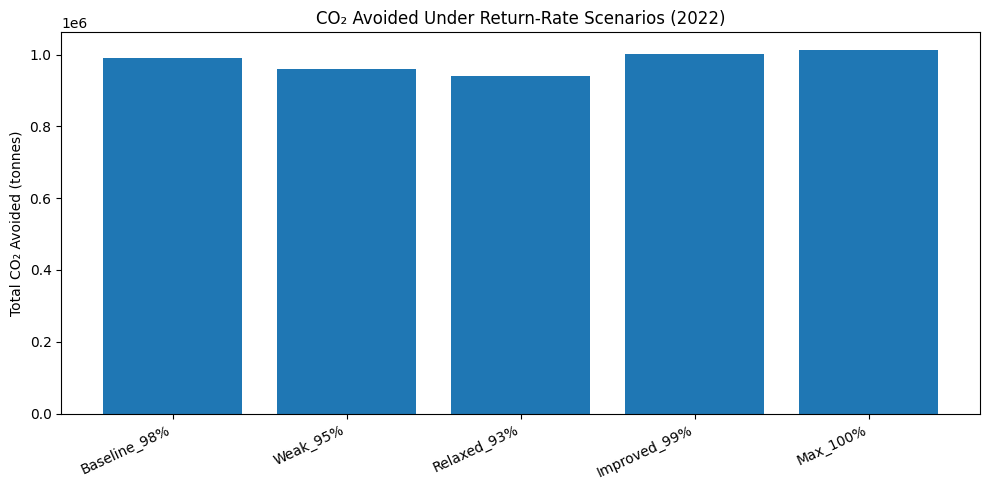

In [10]:
# 1) Bar Chart — Total CO₂ Avoided by Scenario
import matplotlib.pyplot as plt

# make nicer readable numbers
scenario_df_plot = scenario_df.copy()
scenario_df_plot["Total_CO2_Avoided_tonnes"] = scenario_df_plot["Total_CO2_Avoided_tonnes"].round(0)

plt.figure(figsize=(10, 5))
plt.bar(scenario_df_plot["Scenario"], scenario_df_plot["Total_CO2_Avoided_tonnes"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Total CO₂ Avoided (tonnes)")
plt.title("CO₂ Avoided Under Return-Rate Scenarios (2022)")
plt.tight_layout()
plt.show()


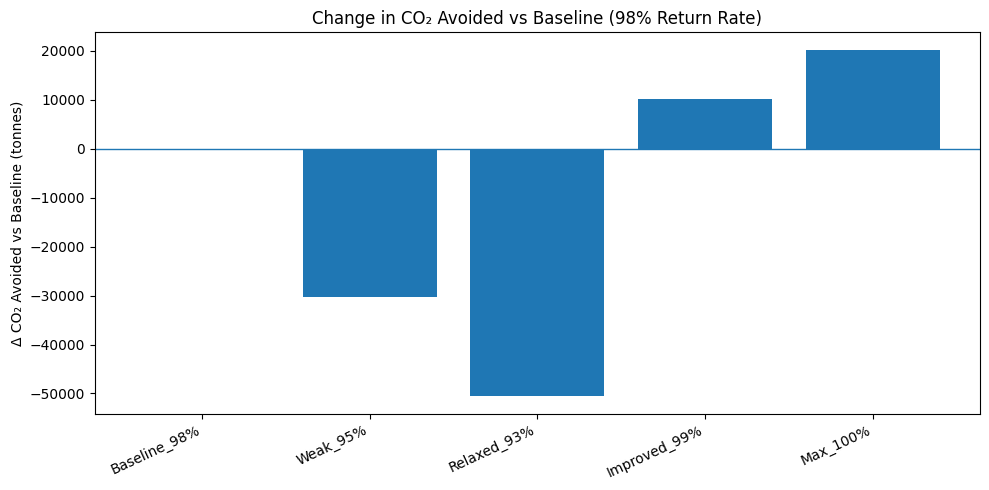

In [11]:
# 2) Bar Chart — Δ CO₂ vs Baseline
plt.figure(figsize=(10, 5))
plt.bar(scenario_df["Scenario"], scenario_df["Delta_vs_Baseline_tonnes"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Δ CO₂ Avoided vs Baseline (tonnes)")
plt.title("Change in CO₂ Avoided vs Baseline (98% Return Rate)")
plt.tight_layout()
plt.show()


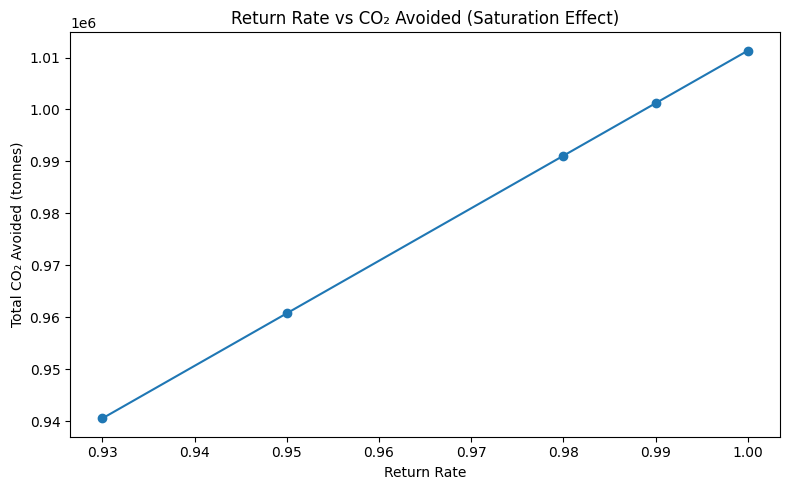

In [12]:
#3) Curve — Return Rate vs CO₂ Avoided (shows saturation)
scenario_sorted = scenario_df.sort_values("Return_Rate")

plt.figure(figsize=(8, 5))
plt.plot(scenario_sorted["Return_Rate"], scenario_sorted["Total_CO2_Avoided_tonnes"], marker="o")
plt.xlabel("Return Rate")
plt.ylabel("Total CO₂ Avoided (tonnes)")
plt.title("Return Rate vs CO₂ Avoided (Saturation Effect)")
plt.tight_layout()
plt.show()


In [13]:
scenario_df.to_csv("../data/cleaned/dashboard_scenario_summary_2022.csv", index=False)


In [14]:
# Export Dashboard KPI Table
baseline_value = float(baseline_value)
kpi_2022 = pd.DataFrame({
    "Metric": [
        "Total_CO2_Avoided_Baseline_tonnes",
        "Baseline_Return_Rate"
    ],
    "Value": [
        round(baseline_value),
        float(BASELINE_RETURN_RATE)   # <-- decimals (0–1), e.g., 0.98
    ]
})

kpi_2022.to_csv("../data/cleaned/dashboard_kpi_2022.csv", index=False)
kpi_2022


,Metric,Value
0,Total_CO2_Avoided_Baseline_tonnes,991082.00
1,Baseline_Return_Rate,0.98
